In [1]:
import sys
print(sys.path)


import aqua
print(aqua.__file__)
from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import matplotlib.pyplot as plt

['c:\\Users\\liamm\\anaconda3\\envs\\aqua\\python313.zip', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua\\DLLs', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua\\Lib', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua', '', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua\\Lib\\site-packages', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua\\Lib\\site-packages\\win32', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\liamm\\anaconda3\\envs\\aqua\\Lib\\site-packages\\Pythonwin']
C:\Users\liamm\Documents\PhD_autapses\Programming_files\AQUA_package\aqua\__init__.py


In [2]:
'''
Will test the STA protocol on filtered white noise injected into the RS_int and RS_res neurons

- need to find the threshold
- Apply a filtered white noise stimulus to this threshold current.

'''

'\nWill test the STA protocol on filtered white noise injected into the RS_int and RS_res neurons\n\n- need to find the threshold\n- Apply a filtered white noise stimulus to this threshold current.\n\n'

## Try again with filtered white noise

In [3]:
### Try again with filtered white noise...

RS_int = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_res = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': 5, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

N_neurons = 50

T = 2    # ms
dt = 0.1    # ms
N_iter = int(1000.*T/dt)

params_int = []
params_res = []

for i in range(N_neurons):
    params_int.append(RS_int)
    params_res.append(RS_res)


batch_int = batchAQUA(params_int)
batch_res = batchAQUA(params_res)

# get threshold and initialisation values
threshold_int, steady_int = batch_int.get_threshold(idx = 0)
threshold_res, steady_res = batch_res.get_threshold(idx = 0)

#reuse threshold and steady-state from before
x_start_int = np.full((N_neurons, 3), fill_value = steady_int)
x_start_res = np.full((N_neurons, 3), fill_value = steady_res)
t_start = np.zeros(N_neurons)

# initialise
batch_int.Initialise(x_start_int, t_start)
batch_res.Initialise(x_start_res, t_start)

# create filtered white noise input
noise_scale = 20    # amplitude     
f_cutoff = 8       # the cutoff frequency
I_noise = np.array([filtered_white_noise_fast(T, dt, amplitude = noise_scale, cutoff = f_cutoff) for i in range(N_neurons)])

#I_noise has mean 0 so we scale up to threshold
I_int = threshold_int + I_noise
I_res = threshold_res + I_noise

# simulate each neuron with noise
X_int, T, spikes_int = batch_int.update_batch(dt, N_iter, I_int)
X_res, T, spikes_res = batch_res.update_batch(dt, N_iter, I_res)


100%|██████████| 19999/19999 [00:03<00:00, 5745.07it/s]


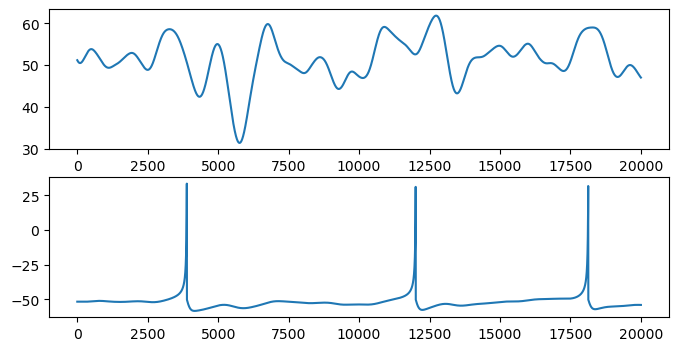

In [4]:

fig, ax = plt.subplots(2, 1, figsize = (8, 4))
idx = 15

ax[0].plot(I_int[idx])

ax[1].plot(X_int[idx, 0, :])



- - STA - - 


100%|██████████| 50/50 [00:00<00:00, 11079.04it/s]


- - STA - - 


100%|██████████| 50/50 [00:00<00:00, 15967.35it/s]


Text(0.5, 0.98, 'STA from white noise input')

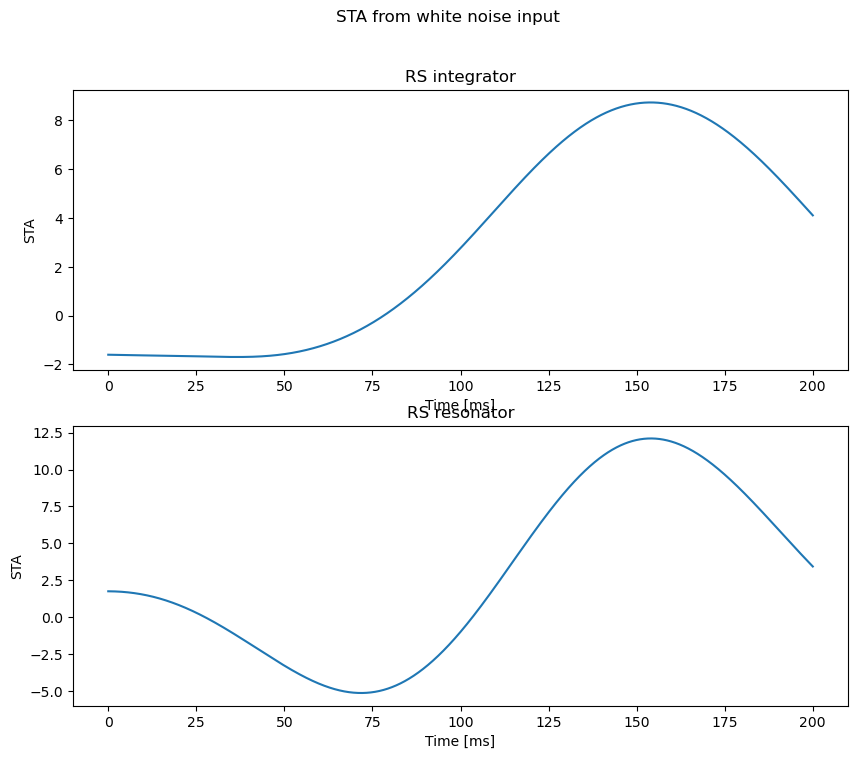

In [5]:
# calculate the STA and plot
window = 2000
STA_int = STA(spikes_int, I_int, dt, window = window)
STA_res = STA(spikes_res, I_res, dt, window = window)

fig, ax = plt.subplots(2, 1, figsize = (10, 8))

time = np.linspace(0, dt*window, window)

ax[0].plot(time, np.mean(STA_int, axis = 0))
ax[1].plot(time, np.mean(STA_res, axis = 0))

ax[0].set_xlabel('Time [ms]')
ax[0].set_ylabel('STA')
ax[0].set_title('RS integrator')

ax[1].set_xlabel('Time [ms]')
ax[1].set_ylabel('STA')
ax[1].set_title('RS resonator')

fig.suptitle("STA from white noise input")

dict_keys([np.float64(2.0), np.float64(50.0)])
501


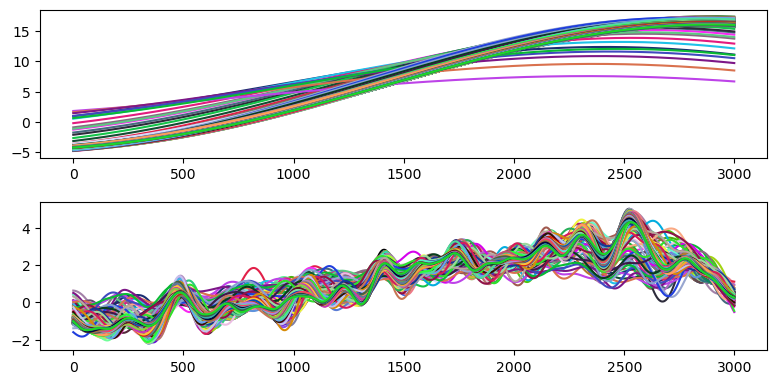

In [11]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

with open(".//RS_intHD//RS_intHD_uniform__STA.pickle", "rb") as file:
    data = pickle.load(file)

print(data.keys())

N_neurons = len(data[2.0])
print(N_neurons)

fig, ax = plt.subplots(2, 1, figsize = (8, 4))
fig.tight_layout()

for i in range(N_neurons):
    if i == 0:
        colour = (0, 0, 0)
    else:
        colour = np.random.rand(3)
    
    ax[0].plot(data[2.0][i], color = colour)

    ax[1].plot(data[50.0][i], color = colour)

